In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

In [3]:
path = Path("../data/raw_data.csv")

data = pd.read_csv(path)

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
data["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [11]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [76]:
data["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Around 26% of customers churn while 74% remain with the telecom company.
This indicates a moderate class imbalance

In [ ]:
data["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

Text(0.5, 1.0, 'Gender Distribution')

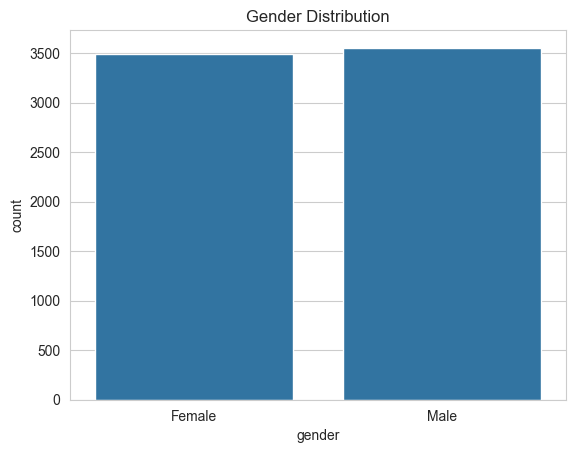

In [77]:
sns.countplot(x = data["gender"])
plt.title("Gender Distribution")

The dataset contains nearly equal numbers of male and female customers.

<Axes: xlabel='tenure', ylabel='Density'>

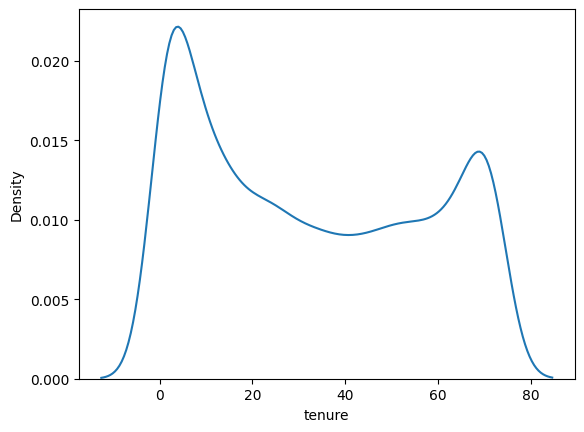

In [27]:
data["tenure"].value_counts()

sns.kdeplot(data=data , x = "tenure")

In [29]:
data["SeniorCitizen"].value_counts(normalize=True)

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64

Most customers are not senior citizens

<Axes: >

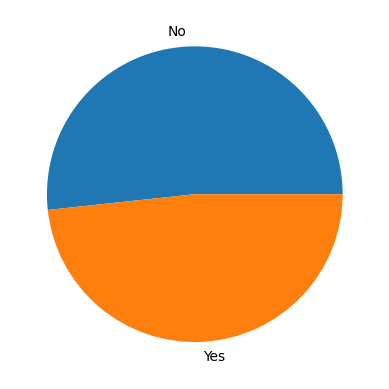

In [33]:
data["Partner"].value_counts().plot(kind="pie")

In [34]:
data["Dependents"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [38]:
data["Dependents"].value_counts(normalize=True)

Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64

<Axes: >

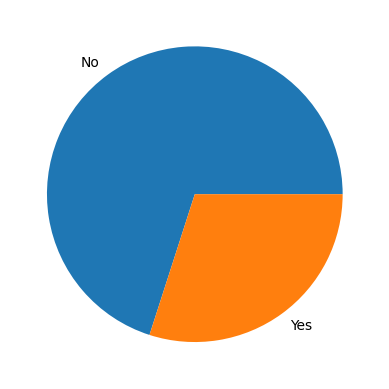

In [37]:
data["Dependents"].value_counts().plot(kind="pie")

In [78]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

<Axes: xlabel='Contract', ylabel='count'>

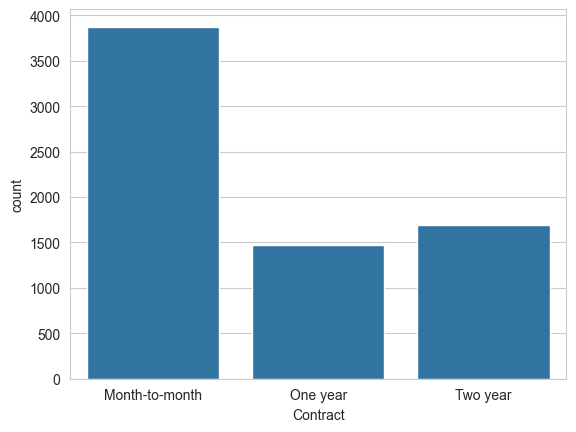

In [80]:
sns.countplot(x = data["Contract"])

Many customers have low tenure, indicating a large number of new customers

In [40]:
data["PhoneService"].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

<Axes: xlabel='PhoneService', ylabel='count'>

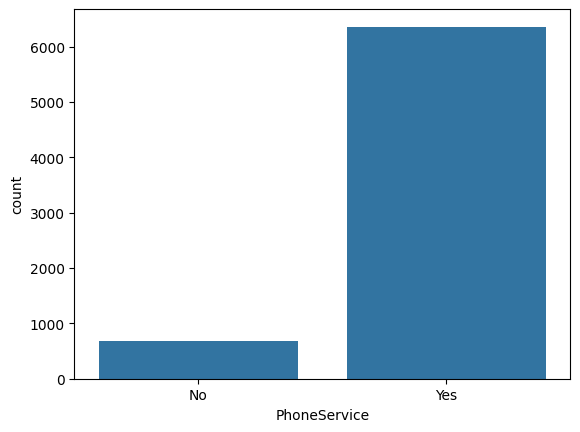

In [41]:
sns.countplot(data=data, x = "PhoneService")

In [42]:
data["MultipleLines"].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

<Axes: xlabel='MultipleLines', ylabel='count'>

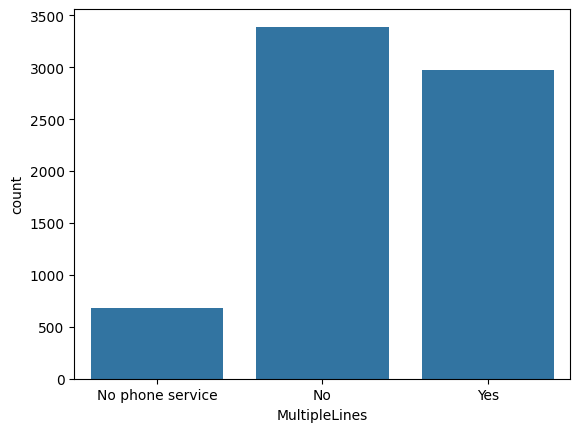

In [44]:
sns.countplot(x = data["MultipleLines"])

In [46]:
data["DeviceProtection"].value_counts(normalize=True)

DeviceProtection
No                     0.439443
Yes                    0.343888
No internet service    0.216669
Name: proportion, dtype: float64

<Axes: >

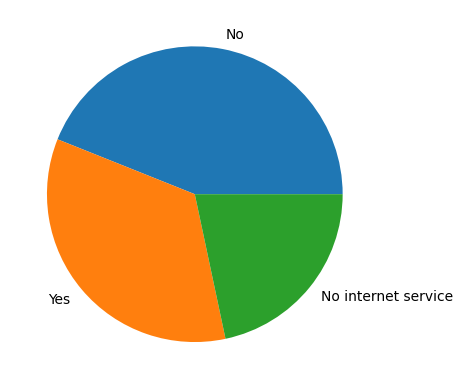

In [47]:
data["DeviceProtection"].value_counts().plot(kind="pie")

In [50]:
data["OnlineBackup"].unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

<Axes: xlabel='count', ylabel='OnlineBackup'>

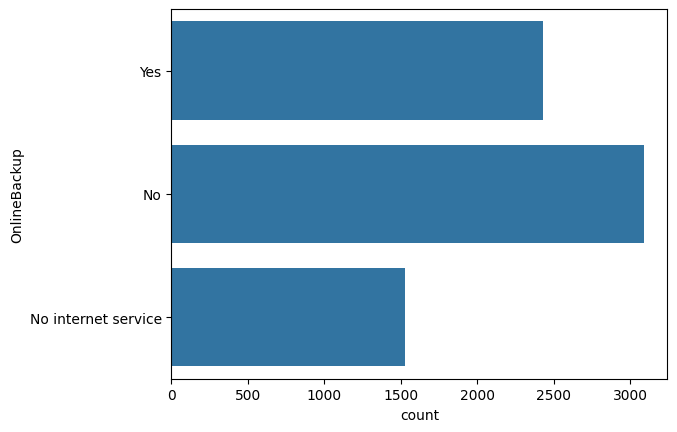

In [57]:
sns.countplot(y = data["OnlineBackup"])

In [60]:
data["PaperlessBilling"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [62]:
data["MonthlyCharges"].value_counts()

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
19.70     43
          ..
72.00      1
108.35     1
63.10      1
44.20      1
78.70      1
Name: count, Length: 1585, dtype: int64

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

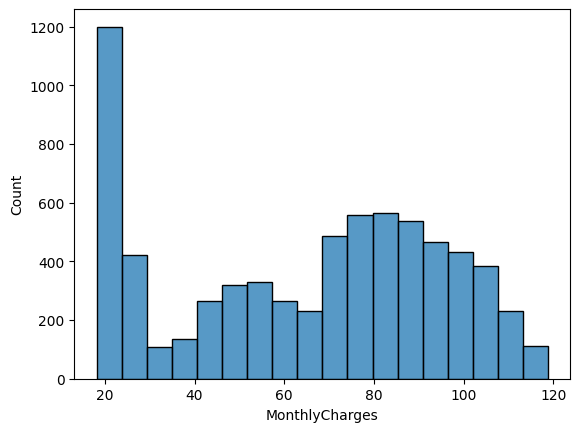

In [65]:
sns.histplot(data=data, x = "MonthlyCharges")

In [67]:
data["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

<Axes: xlabel='PaymentMethod', ylabel='count'>

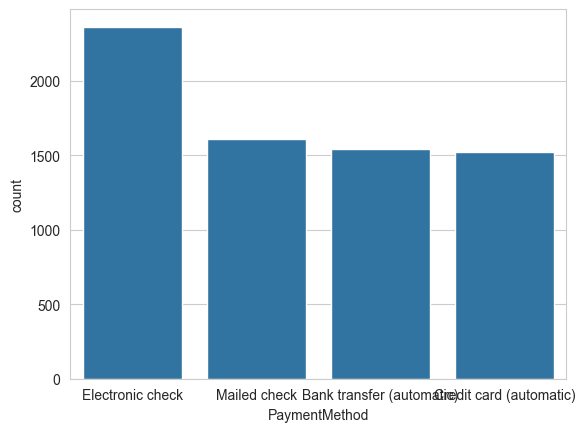

In [74]:
sns.countplot(x = data["PaymentMethod"])

<Axes: ylabel='TotalCharges'>

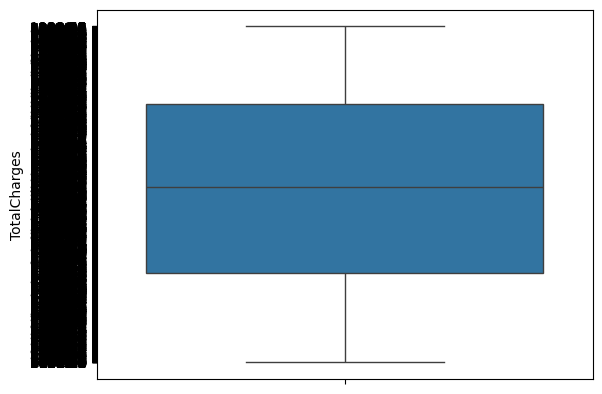

In [72]:
sns.boxplot(data["TotalCharges"])

<!-- ### Bi-Variate Anlaysis -->

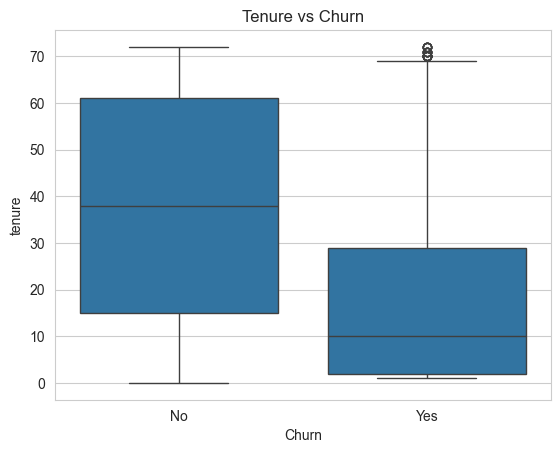

In [84]:
# Do new customers churn more than long-term customers?

sns.boxplot(x="Churn", y="tenure", data=data)
plt.title("Tenure vs Churn")
plt.show()

New customers churn significantly more than long-term customers

Text(0.5, 1.0, 'Contract Type vs Churn')

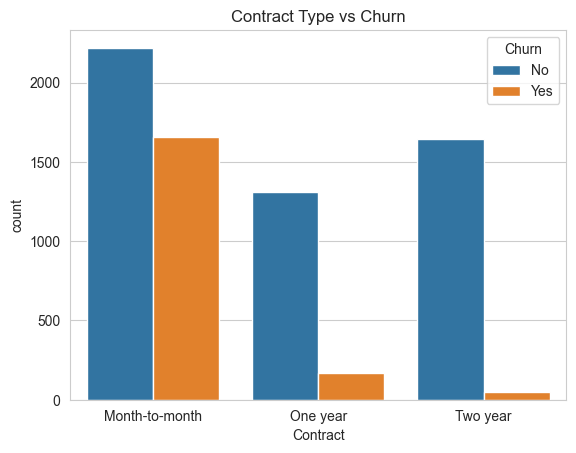

In [86]:
# Does contract type influence churn?

sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Contract Type vs Churn")

Customers on month-to-month contracts churn far more than yearly contracts

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

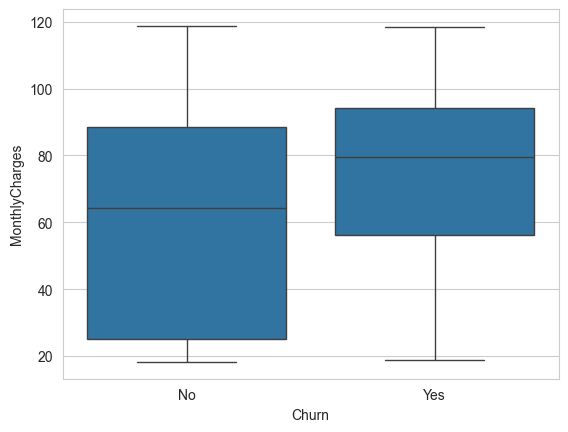

In [88]:
# Do customers with higher monthly charges churn more?

sns.boxplot(x = "Churn", y = "MonthlyCharges", data=data)

Customers paying higher monthly charges churn slightly more.

Text(0.5, 1.0, 'Internet Service vs Churn')

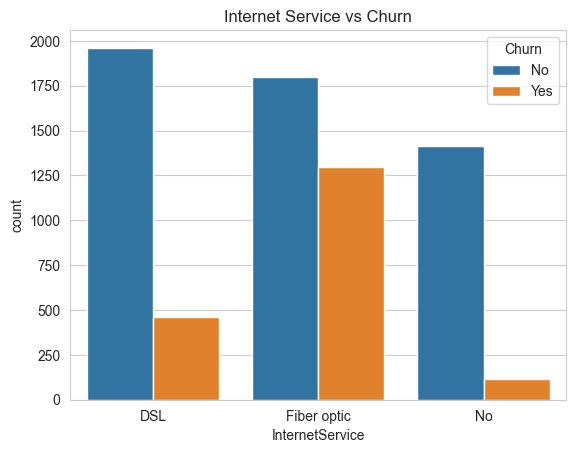

In [89]:
# Does internet service type affect churn?

sns.countplot(x="InternetService", hue="Churn", data=data)
plt.title("Internet Service vs Churn")

Fiber optic users churn more than DSL users

Text(0.5, 1.0, 'Tech Support vs Churn')

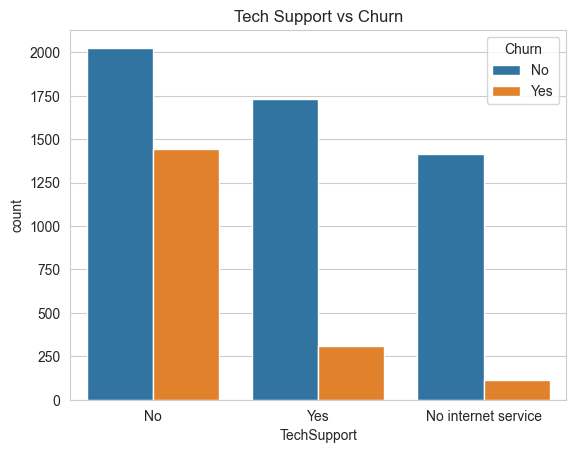

In [91]:
# Do customers with tech support churn less?

sns.countplot(x="TechSupport", hue="Churn", data=data)
plt.title("Tech Support vs Churn")

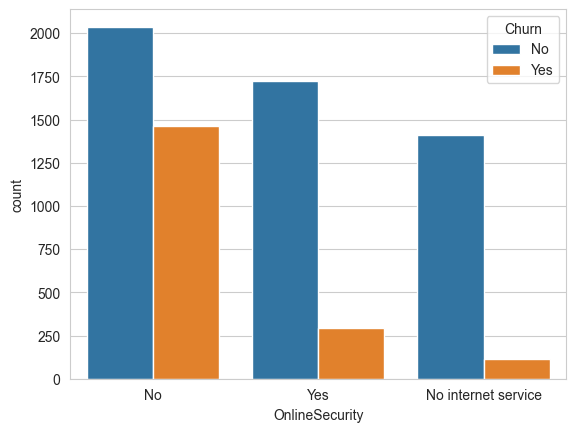

In [94]:
# Does online security influence churn?

sns.countplot(x="OnlineSecurity", hue="Churn", data=data)
plt.show()


df.columns

In [93]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

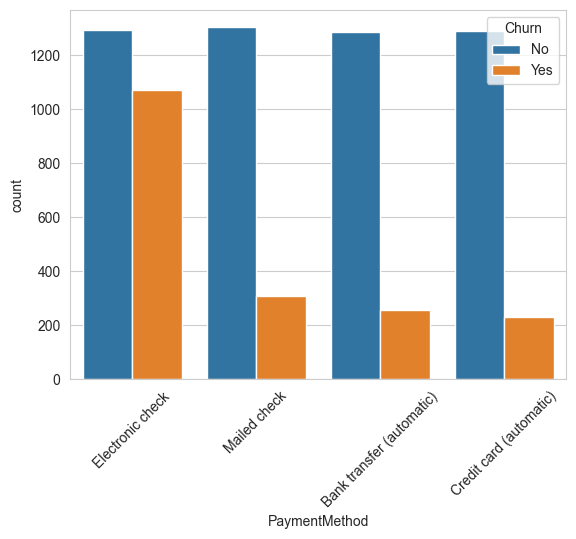

In [98]:
# oes payment method influence churn?

sns.countplot(x = "PaymentMethod", hue="Churn", data=data)
plt.xticks(rotation = 45)
plt.show()

Customers using electronic check churn more frequently.

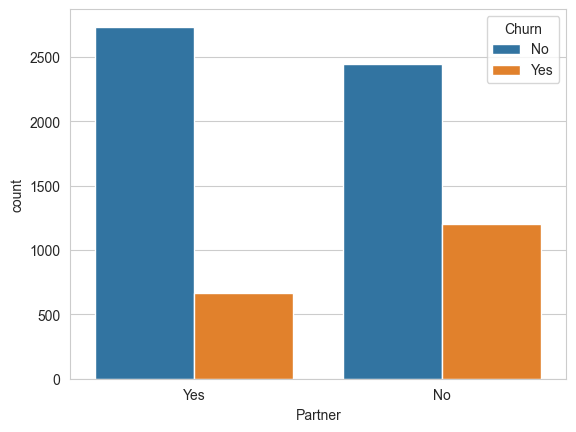

In [99]:
# Does having a partner reduce churn?

sns.countplot(x = "Partner", hue= "Churn", data=data)
plt.show()

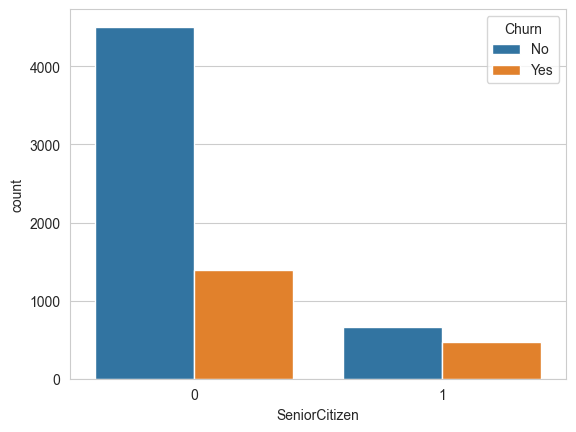

In [100]:
# Do senior citizens churn more?

sns.countplot(x = "SeniorCitizen", hue="Churn", data=data)
plt.show()